# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Multimodal Analysis

## Merge both modalities

In [3]:
# Load CSV files
visual_df = pd.read_csv("Data/Images/Output/person_detections_with_face_attributes.csv")
textual_df = pd.read_csv("Data/Articles/Output/Articles_merged_enriched.csv")

# Prepare visual data

# Crowding = number of detected persons in same image
visual_df["persons_in_image"] = (
    visual_df.groupby("image_name")["person_instance_id"]
    .transform("count")
)

# Off-centre score = 1 - centrality
visual_df["off_center_score"] = 1 - visual_df["centrality"]
visual_df["off_center_score"] = visual_df["off_center_score"].clip(0, 1)

# Keep only accepted face detections with estimated race
faces_df = visual_df[
    (visual_df["face_found"] == 1) &
    (visual_df["face_race"].notna())
].copy()

# Clean race labels
faces_df["Model-estimated Race"] = (
    faces_df["face_race"]
    .astype(str)
    .str.replace("_", " ")
    .str.title()
)

# Prepare textual data

# Article-level sentiment column
sentiment_col = "sent_article_label"

# Article-level frame columns
frame_cols = [
    "crime_frame",
    "humanitarian_frame",
    "burden_frame",
    "security_frame",
    "economic_frame",
    "integration_frame"
]

# Keep only columns needed for multimodal analysis
text_cols = ["article_id", sentiment_col] + frame_cols

textual_small = textual_df[text_cols].copy()

# Make sure frame columns are numeric
for col in frame_cols:
    textual_small[col] = pd.to_numeric(textual_small[col], errors="coerce").fillna(0)

# Clean sentiment labels
textual_small[sentiment_col] = (
    textual_small[sentiment_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Merge visual and textual data
multimodal_df = faces_df.merge(
    textual_small,
    on="article_id",
    how="inner"
)

print("Accepted face detections:", len(faces_df))
print("Multimodal rows after merge:", len(multimodal_df))
print("Unique multimodal articles:", multimodal_df["article_id"].nunique())

display(multimodal_df.head())

Accepted face detections: 14278
Multimodal rows after merge: 14278
Unique multimodal articles: 7656


,article_id,article_url,image_name,filename,image_path,image_width,image_height,image_area,person_instance_id,bbox_x1,...,persons_in_image,off_center_score,Model-estimated Race,sent_article_label,crime_frame,humanitarian_frame,burden_frame,security_frame,economic_frame,integration_frame
0,100,https://www.maltatoday.com.mt/news/data_and_su...,100.png,100.png,Data\Images\Plain_Images\100.png,3000,1688,5064000.0,100_p0,1626,...,2,0.463568,White,neutral,0,0,0,0,0,0
1,100,https://www.maltatoday.com.mt/news/data_and_su...,100.png,100.png,Data\Images\Plain_Images\100.png,3000,1688,5064000.0,100_p1,69,...,2,0.407410,White,neutral,0,0,0,0,0,0
2,10000,https://timesofmalta.com/article/government-fo...,10000.jpg,10000.jpg,Data\Images\Plain_Images\10000.jpg,1620,1080,1749600.0,10000_p1,729,...,12,0.200388,Middle Eastern,positive,0,0,0,0,0,0
3,10001,https://timesofmalta.com/article/have-seen-man...,10001.jpg,10001.jpg,Data\Images\Plain_Images\10001.jpg,1920,1280,2457600.0,10001_p0,469,...,1,0.054688,Middle Eastern,neutral,0,0,0,0,0,0
4,10004,https://timesofmalta.com/article/metsola-cites...,10004.jpg,10004.jpg,Data\Images\Plain_Images\10004.jpg,1102,738,813276.0,10004_p1,532,...,2,0.207719,White,neutral,0,0,0,0,0,0


## Sentiment x Race

sent_article_label,negative,neutral,positive
Model-estimated Race,,,
Asian,208,179,320
Black,117,95,146
Indian,38,21,30
Latino Hispanic,246,210,217
Middle Eastern,961,609,823
White,3611,2753,3694


sent_article_label,negative,neutral,positive
Model-estimated Race,,,
Asian,29.4,25.3,45.3
Black,32.7,26.5,40.8
Indian,42.7,23.6,33.7
Latino Hispanic,36.6,31.2,32.2
Middle Eastern,40.2,25.4,34.4
White,35.9,27.4,36.7


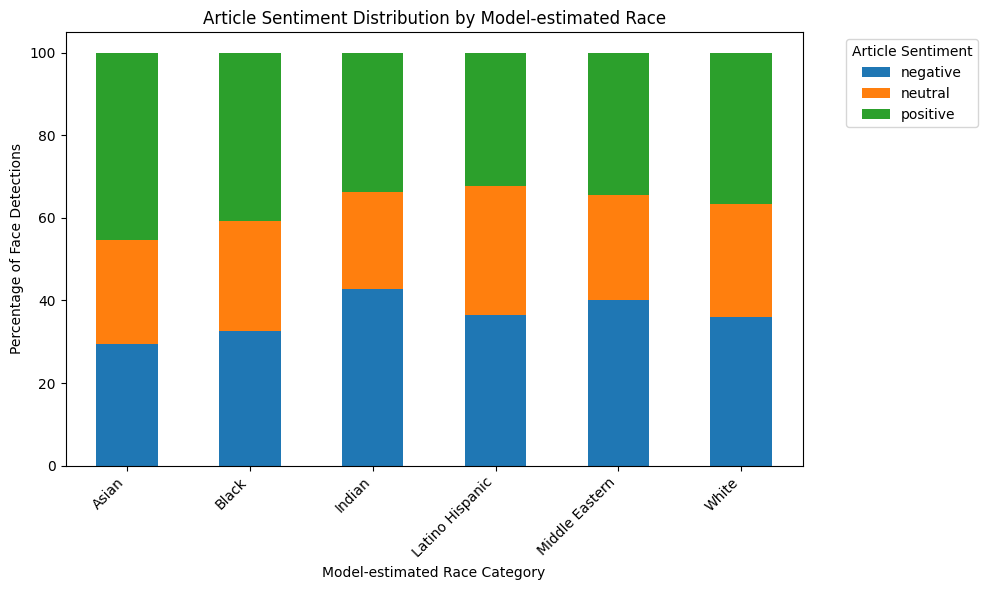

In [4]:
# Sentiment x Race
sentiment_race_counts = pd.crosstab(
    multimodal_df["Model-estimated Race"],
    multimodal_df[sentiment_col]
)

sentiment_race_percent = pd.crosstab(
    multimodal_df["Model-estimated Race"],
    multimodal_df[sentiment_col],
    normalize="index"
) * 100

sentiment_race_percent = sentiment_race_percent.round(1)

display(sentiment_race_counts)
display(sentiment_race_percent)

# Plot
sentiment_order = ["negative", "neutral", "positive"]
existing_sentiments = [s for s in sentiment_order if s in sentiment_race_percent.columns]

plot_df = sentiment_race_percent[existing_sentiments]

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Article Sentiment Distribution by Model-estimated Race")
plt.xlabel("Model-estimated Race Category")
plt.ylabel("Percentage of Face Detections")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Article Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Framing x Race

,Crime,Humanitarian,Burden,Security,Economic,Integration
Model-estimated Race,,,,,,
Asian,18.4,8.2,2.4,7.6,19.7,5.2
Black,27.9,12.3,0.6,17.3,21.2,5.3
Indian,39.3,7.9,0.0,18.0,15.7,4.5
Latino Hispanic,23.6,6.2,1.5,6.2,20.5,2.8
Middle Eastern,26.4,6.8,1.9,6.9,19.1,3.0
White,22.8,7.3,2.0,6.8,20.8,4.1


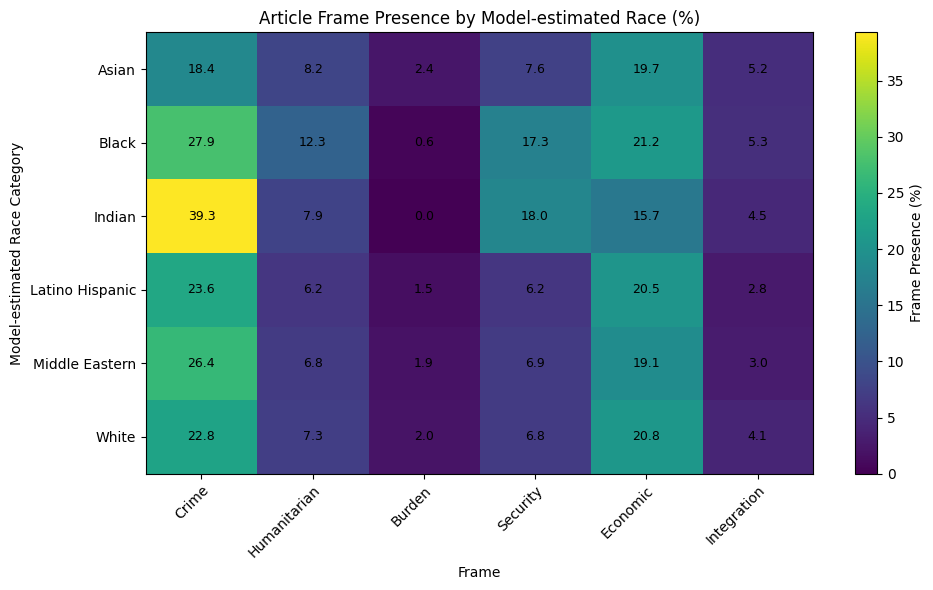

In [5]:

# Framing x Race
frame_labels = {
    "crime_frame": "Crime",
    "humanitarian_frame": "Humanitarian",
    "burden_frame": "Burden",
    "security_frame": "Security",
    "economic_frame": "Economic",
    "integration_frame": "Integration"
}

frame_race_table = (
    multimodal_df
    .groupby("Model-estimated Race")[frame_cols]
    .mean() * 100
)

frame_race_table = frame_race_table.rename(columns=frame_labels).round(1)

display(frame_race_table)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

data = frame_race_table.values
im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(frame_race_table.columns)))
ax.set_yticks(np.arange(len(frame_race_table.index)))

ax.set_xticklabels(frame_race_table.columns)
ax.set_yticklabels(frame_race_table.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add values inside cells
for i in range(len(frame_race_table.index)):
    for j in range(len(frame_race_table.columns)):
        ax.text(
            j,
            i,
            f"{data[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title("Article Frame Presence by Model-estimated Race (%)")
ax.set_xlabel("Frame")
ax.set_ylabel("Model-estimated Race Category")

cbar = plt.colorbar(im)
cbar.set_label("Frame Presence (%)")

plt.tight_layout()
plt.show()

## Crowding and off-centre score by article sentiment

,Article Sentiment,Total Faces,Mean Persons in Image,Mean Off-centre Score,Mean Visibility Score
0,negative,5181,5.12,0.369,0.437
1,neutral,3867,5.65,0.375,0.414
2,positive,5230,6.69,0.374,0.378


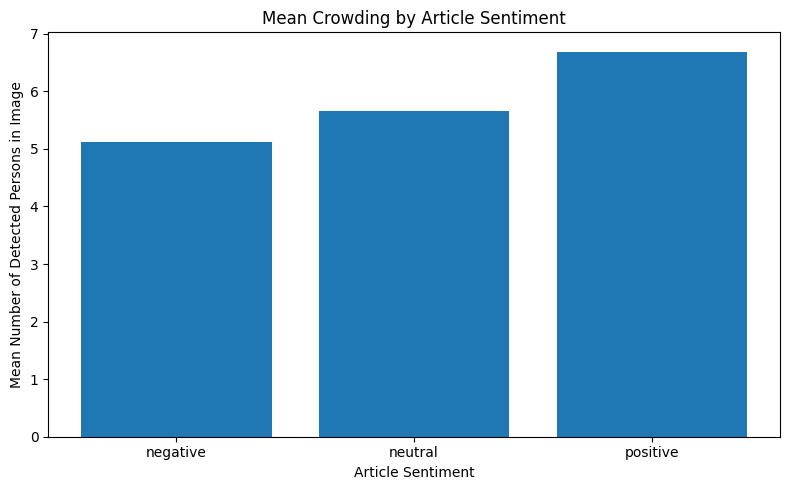

In [6]:
# Crowding by Sentiment
crowding_sentiment_table = (
    multimodal_df
    .groupby(sentiment_col)
    .agg(
        total_faces=("Model-estimated Race", "size"),
        mean_persons_in_image=("persons_in_image", "mean"),
        mean_off_center_score=("off_center_score", "mean"),
        mean_visibility_score=("visibility_score", "mean")
    )
    .reset_index()
)

crowding_sentiment_table = crowding_sentiment_table.round({
    "mean_persons_in_image": 2,
    "mean_off_center_score": 3,
    "mean_visibility_score": 3
})

crowding_sentiment_table = crowding_sentiment_table.rename(columns={
    sentiment_col: "Article Sentiment",
    "total_faces": "Total Faces",
    "mean_persons_in_image": "Mean Persons in Image",
    "mean_off_center_score": "Mean Off-centre Score",
    "mean_visibility_score": "Mean Visibility Score"
})

display(crowding_sentiment_table)

# Plot mean persons in image by sentiment
plot_df = crowding_sentiment_table.copy()

plt.figure(figsize=(8, 5))
plt.bar(
    plot_df["Article Sentiment"],
    plot_df["Mean Persons in Image"]
)

plt.title("Mean Crowding by Article Sentiment")
plt.xlabel("Article Sentiment")
plt.ylabel("Mean Number of Detected Persons in Image")
plt.tight_layout()
plt.show()

## Crowding by Sentiment × Race

In [7]:

# Crowding by Sentiment x Race
crowding_sentiment_race_table = (
    multimodal_df
    .groupby(["Model-estimated Race", sentiment_col])
    .agg(
        total_faces=("Model-estimated Race", "size"),
        mean_persons_in_image=("persons_in_image", "mean"),
        mean_off_center_score=("off_center_score", "mean"),
        mean_visibility_score=("visibility_score", "mean")
    )
    .reset_index()
)

crowding_sentiment_race_table = crowding_sentiment_race_table.round({
    "mean_persons_in_image": 2,
    "mean_off_center_score": 3,
    "mean_visibility_score": 3
})

crowding_sentiment_race_table = crowding_sentiment_race_table.rename(columns={
    sentiment_col: "Article Sentiment",
    "total_faces": "Total Faces",
    "mean_persons_in_image": "Mean Persons in Image",
    "mean_off_center_score": "Mean Off-centre Score",
    "mean_visibility_score": "Mean Visibility Score"
})

display(crowding_sentiment_race_table)

,Model-estimated Race,Article Sentiment,Total Faces,Mean Persons in Image,Mean Off-centre Score,Mean Visibility Score
0,Asian,negative,208,6.93,0.410,0.380
1,Asian,neutral,179,7.21,0.412,0.354
2,Asian,positive,320,7.68,0.412,0.342
3,Black,negative,117,6.98,0.370,0.423
4,Black,neutral,95,7.29,0.428,0.383
5,Black,positive,146,8.40,0.433,0.334
6,Indian,negative,38,5.50,0.421,0.380
7,Indian,neutral,21,6.52,0.404,0.388
8,Indian,positive,30,7.33,0.463,0.321
9,Latino Hispanic,negative,246,4.44,0.339,0.471


## Crowding heatmap by Sentiment × Race

sent_article_label,negative,neutral,positive
Model-estimated Race,,,
Asian,6.93,7.21,7.68
Black,6.98,7.29,8.40
Indian,5.50,6.52,7.33
Latino Hispanic,4.44,5.78,6.40
Middle Eastern,4.84,5.72,6.62
White,5.07,5.47,6.56


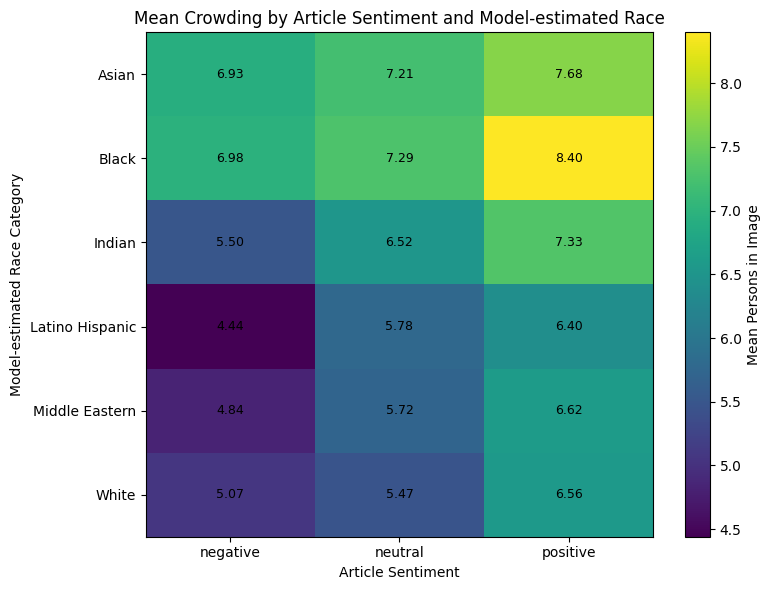

In [8]:
# Crowding heatmap: Race x Sentiment
crowding_heatmap = multimodal_df.pivot_table(
    index="Model-estimated Race",
    columns=sentiment_col,
    values="persons_in_image",
    aggfunc="mean"
)

crowding_heatmap = crowding_heatmap.round(2)

display(crowding_heatmap)

fig, ax = plt.subplots(figsize=(8, 6))

data = crowding_heatmap.values
im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(crowding_heatmap.columns)))
ax.set_yticks(np.arange(len(crowding_heatmap.index)))

ax.set_xticklabels(crowding_heatmap.columns)
ax.set_yticklabels(crowding_heatmap.index)

for i in range(len(crowding_heatmap.index)):
    for j in range(len(crowding_heatmap.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

ax.set_title("Mean Crowding by Article Sentiment and Model-estimated Race")
ax.set_xlabel("Article Sentiment")
ax.set_ylabel("Model-estimated Race Category")
cbar = plt.colorbar(im)
cbar.set_label("Mean Persons in Image")
plt.tight_layout()
plt.show()

## Visibility by article sentiment

In [9]:
# Visibility by Article Sentiment
visibility_sentiment_table = (
    multimodal_df
    .groupby(sentiment_col)
    .agg(
        total_faces=("Model-estimated Race", "size"),
        mean_visibility_score=("visibility_score", "mean"),
        mean_relative_area=("relative_area", "mean"),
        mean_centrality=("centrality", "mean"),
        mean_off_center_score=("off_center_score", "mean"),
        mean_face_brightness=("face_brightness", "mean"),
        blurry_face_rate=("face_is_blurry", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).mean() * 100),
        dark_face_rate=("face_is_dark", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).mean() * 100)
    )
    .reset_index()
)

visibility_sentiment_table = visibility_sentiment_table.round({
    "mean_visibility_score": 3,
    "mean_relative_area": 3,
    "mean_centrality": 3,
    "mean_off_center_score": 3,
    "mean_face_brightness": 1,
    "blurry_face_rate": 2,
    "dark_face_rate": 2
})

visibility_sentiment_table = visibility_sentiment_table.rename(columns={
    sentiment_col: "Article Sentiment",
    "total_faces": "Total Faces",
    "mean_visibility_score": "Mean Visibility Score",
    "mean_relative_area": "Mean Relative Area",
    "mean_centrality": "Mean Centrality",
    "mean_off_center_score": "Mean Off-centre Score",
    "mean_face_brightness": "Mean Face Brightness",
    "blurry_face_rate": "Blurry Face Rate (%)",
    "dark_face_rate": "Dark Face Rate (%)"
})

display(visibility_sentiment_table)

,Article Sentiment,Total Faces,Mean Visibility Score,Mean Relative Area,Mean Centrality,Mean Off-centre Score,Mean Face Brightness,Blurry Face Rate (%),Dark Face Rate (%)
0,negative,5181,0.437,0.307,0.631,0.369,125.7,27.60,1.29
1,neutral,3867,0.414,0.273,0.625,0.375,127.1,22.91,1.37
2,positive,5230,0.378,0.213,0.626,0.374,126.9,13.15,1.22


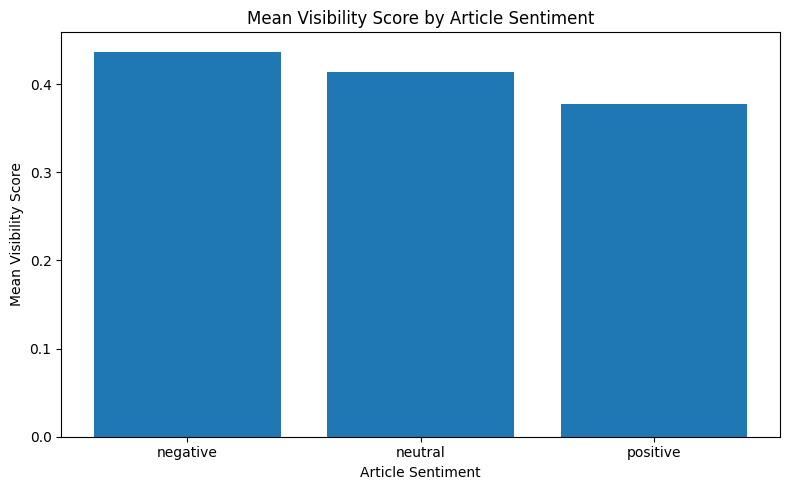

In [10]:
# Bar chart of mean visibility by article sentiment
plot_df = visibility_sentiment_table.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["Article Sentiment"],
    plot_df["Mean Visibility Score"]
)

plt.title("Mean Visibility Score by Article Sentiment")
plt.xlabel("Article Sentiment")
plt.ylabel("Mean Visibility Score")
plt.tight_layout()
plt.show()

## Visibility by article sentiment and estimated race

In [11]:
# Visibility by Sentiment x Race
visibility_sentiment_race_table = (
    multimodal_df
    .groupby(["Model-estimated Race", sentiment_col])
    .agg(
        total_faces=("Model-estimated Race", "size"),
        mean_visibility_score=("visibility_score", "mean"),
        mean_relative_area=("relative_area", "mean"),
        mean_centrality=("centrality", "mean"),
        mean_off_center_score=("off_center_score", "mean"),
        mean_face_brightness=("face_brightness", "mean"),
        blurry_face_rate=("face_is_blurry", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).mean() * 100),
        dark_face_rate=("face_is_dark", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).mean() * 100)
    )
    .reset_index()
)

visibility_sentiment_race_table = visibility_sentiment_race_table.round({
    "mean_visibility_score": 3,
    "mean_relative_area": 3,
    "mean_centrality": 3,
    "mean_off_center_score": 3,
    "mean_face_brightness": 1,
    "blurry_face_rate": 2,
    "dark_face_rate": 2
})

visibility_sentiment_race_table = visibility_sentiment_race_table.rename(columns={
    sentiment_col: "Article Sentiment",
    "total_faces": "Total Faces",
    "mean_visibility_score": "Mean Visibility Score",
    "mean_relative_area": "Mean Relative Area",
    "mean_centrality": "Mean Centrality",
    "mean_off_center_score": "Mean Off-centre Score",
    "mean_face_brightness": "Mean Face Brightness",
    "blurry_face_rate": "Blurry Face Rate (%)",
    "dark_face_rate": "Dark Face Rate (%)"
})

display(visibility_sentiment_race_table)

,Model-estimated Race,Article Sentiment,Total Faces,Mean Visibility Score,Mean Relative Area,Mean Centrality,Mean Off-centre Score,Mean Face Brightness,Blurry Face Rate (%),Dark Face Rate (%)
0,Asian,negative,208,0.380,0.239,0.590,0.410,116.1,29.33,4.33
1,Asian,neutral,179,0.354,0.199,0.588,0.412,115.9,31.84,2.23
2,Asian,positive,320,0.342,0.179,0.588,0.412,123.1,15.62,1.25
3,Black,negative,117,0.423,0.286,0.630,0.370,102.3,26.50,4.27
4,Black,neutral,95,0.383,0.258,0.572,0.428,90.7,30.53,8.42
5,Black,positive,146,0.334,0.179,0.567,0.433,96.0,13.70,11.64
6,Indian,negative,38,0.380,0.247,0.579,0.421,97.2,26.32,0.00
7,Indian,neutral,21,0.388,0.249,0.596,0.404,105.5,4.76,0.00
8,Indian,positive,30,0.321,0.177,0.537,0.463,103.6,16.67,6.67
9,Latino Hispanic,negative,246,0.471,0.344,0.661,0.339,120.2,31.30,2.03


sent_article_label,negative,neutral,positive
Model-estimated Race,,,
Asian,0.380,0.354,0.342
Black,0.423,0.383,0.334
Indian,0.380,0.388,0.321
Latino Hispanic,0.471,0.442,0.387
Middle Eastern,0.455,0.414,0.372
White,0.434,0.417,0.384


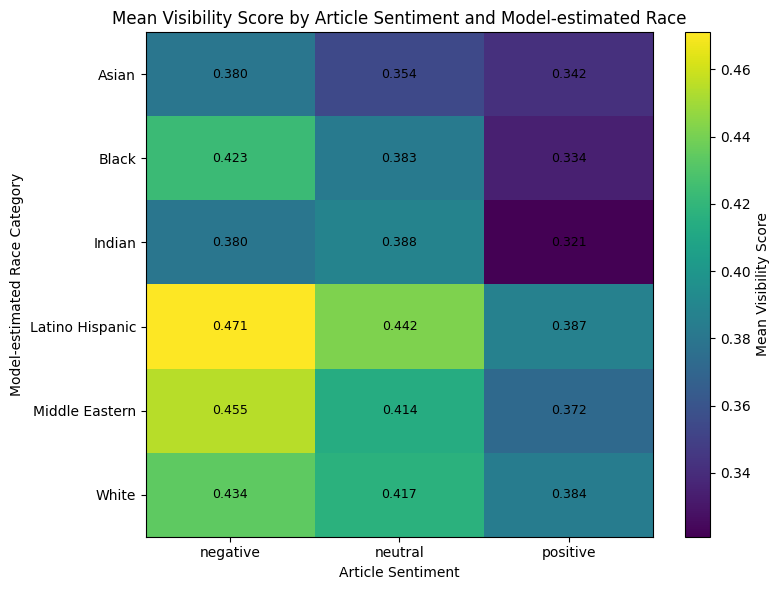

In [12]:
# Heatmap: mean visibility score by race and sentiment
visibility_sentiment_heatmap = multimodal_df.pivot_table(
    index="Model-estimated Race",
    columns=sentiment_col,
    values="visibility_score",
    aggfunc="mean"
).round(3)

display(visibility_sentiment_heatmap)

fig, ax = plt.subplots(figsize=(8, 6))

data = visibility_sentiment_heatmap.values
im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(visibility_sentiment_heatmap.columns)))
ax.set_yticks(np.arange(len(visibility_sentiment_heatmap.index)))

ax.set_xticklabels(visibility_sentiment_heatmap.columns)
ax.set_yticklabels(visibility_sentiment_heatmap.index)

for i in range(len(visibility_sentiment_heatmap.index)):
    for j in range(len(visibility_sentiment_heatmap.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=9
            )

ax.set_title("Mean Visibility Score by Article Sentiment and Model-estimated Race")
ax.set_xlabel("Article Sentiment")
ax.set_ylabel("Model-estimated Race Category")

cbar = plt.colorbar(im)
cbar.set_label("Mean Visibility Score")

plt.tight_layout()
plt.show()

## Visibility by article frame

In [13]:
# Visibility by Frame
visibility_by_frame_rows = []

for frame in frame_cols:
    frame_articles = multimodal_df[multimodal_df[frame] == 1].copy()
    
    visibility_by_frame_rows.append({
        "Frame": frame_labels.get(frame, frame),
        "Total Faces": len(frame_articles),
        "Mean Visibility Score": frame_articles["visibility_score"].mean(),
        "Mean Relative Area": frame_articles["relative_area"].mean(),
        "Mean Centrality": frame_articles["centrality"].mean(),
        "Mean Off-centre Score": frame_articles["off_center_score"].mean(),
        "Mean Persons in Image": frame_articles["persons_in_image"].mean(),
        "Mean Face Brightness": frame_articles["face_brightness"].mean(),
        "Blurry Face Rate (%)": pd.to_numeric(frame_articles["face_is_blurry"], errors="coerce").fillna(0).mean() * 100,
        "Dark Face Rate (%)": pd.to_numeric(frame_articles["face_is_dark"], errors="coerce").fillna(0).mean() * 100
    })

visibility_frame_table = pd.DataFrame(visibility_by_frame_rows)

visibility_frame_table = visibility_frame_table.round({
    "Mean Visibility Score": 3,
    "Mean Relative Area": 3,
    "Mean Centrality": 3,
    "Mean Off-centre Score": 3,
    "Mean Persons in Image": 2,
    "Mean Face Brightness": 1,
    "Blurry Face Rate (%)": 2,
    "Dark Face Rate (%)": 2
})

display(visibility_frame_table)

,Frame,Total Faces,Mean Visibility Score,Mean Relative Area,Mean Centrality,Mean Off-centre Score,Mean Persons in Image,Mean Face Brightness,Blurry Face Rate (%),Dark Face Rate (%)
0,Crime,3353,0.442,0.311,0.638,0.362,5.07,125.6,31.05,1.64
1,Humanitarian,1045,0.396,0.243,0.625,0.375,6.12,126.4,18.95,1.72
2,Burden,281,0.402,0.250,0.630,0.370,5.47,125.2,16.01,2.14
3,Security,1026,0.400,0.249,0.625,0.375,6.45,125.5,25.15,1.75
4,Economic,2912,0.401,0.247,0.632,0.368,6.10,128.5,18.72,1.06
5,Integration,566,0.376,0.212,0.623,0.377,6.61,125.1,11.13,1.06


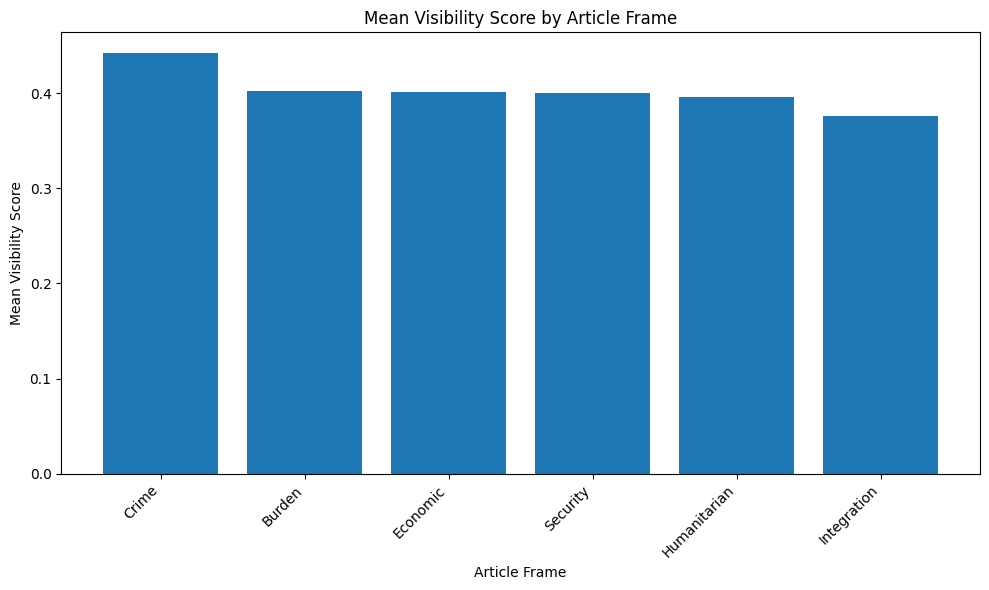

In [14]:
# Bar chart: visibility by frame
plot_df = visibility_frame_table.sort_values(
    "Mean Visibility Score",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_df["Frame"],
    plot_df["Mean Visibility Score"]
)

plt.title("Mean Visibility Score by Article Frame")
plt.xlabel("Article Frame")
plt.ylabel("Mean Visibility Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visibility by frame and estimated race

In [15]:
# Visibility by Frame x Race
frame_race_visibility_rows = []

for frame in frame_cols:
    frame_df = multimodal_df[multimodal_df[frame] == 1].copy()
    
    grouped = (
        frame_df
        .groupby("Model-estimated Race")
        .agg(
            total_faces=("Model-estimated Race", "size"),
            mean_visibility_score=("visibility_score", "mean"),
            mean_persons_in_image=("persons_in_image", "mean"),
            mean_off_center_score=("off_center_score", "mean"),
            mean_face_brightness=("face_brightness", "mean")
        )
        .reset_index()
    )
    
    grouped["Frame"] = frame_labels.get(frame, frame)
    frame_race_visibility_rows.append(grouped)

visibility_frame_race_table = pd.concat(
    frame_race_visibility_rows,
    ignore_index=True
)

visibility_frame_race_table = visibility_frame_race_table[
    [
        "Frame",
        "Model-estimated Race",
        "total_faces",
        "mean_visibility_score",
        "mean_persons_in_image",
        "mean_off_center_score",
        "mean_face_brightness"
    ]
]

visibility_frame_race_table = visibility_frame_race_table.rename(columns={
    "total_faces": "Total Faces",
    "mean_visibility_score": "Mean Visibility Score",
    "mean_persons_in_image": "Mean Persons in Image",
    "mean_off_center_score": "Mean Off-centre Score",
    "mean_face_brightness": "Mean Face Brightness"
})

visibility_frame_race_table = visibility_frame_race_table.round({
    "Mean Visibility Score": 3,
    "Mean Persons in Image": 2,
    "Mean Off-centre Score": 3,
    "Mean Face Brightness": 1
})

display(visibility_frame_race_table)

,Frame,Model-estimated Race,Total Faces,Mean Visibility Score,Mean Persons in Image,Mean Off-centre Score,Mean Face Brightness
0,Crime,Asian,130,0.384,6.89,0.409,115.3
1,Crime,Black,100,0.432,6.81,0.379,96.9
2,Crime,Indian,35,0.371,5.69,0.409,101.9
3,Crime,Latino Hispanic,159,0.441,4.38,0.366,117.1
4,Crime,Middle Eastern,631,0.463,4.75,0.340,124.8
5,Crime,White,2298,0.441,5.01,0.364,128.7
6,Humanitarian,Asian,58,0.357,6.90,0.401,126.6
7,Humanitarian,Black,44,0.314,9.34,0.484,87.9
8,Humanitarian,Indian,7,0.309,6.14,0.474,96.0
9,Humanitarian,Latino Hispanic,42,0.416,5.55,0.355,122.1


Frame,Burden,Crime,Economic,Humanitarian,Integration,Security
Model-estimated Race,,,,,,
Asian,0.356,0.384,0.331,0.357,0.378,0.344
Black,0.403,0.432,0.346,0.314,0.331,0.324
Indian,NaN,0.371,0.357,0.309,0.211,0.354
Latino Hispanic,0.369,0.441,0.428,0.416,0.369,0.421
Middle Eastern,0.439,0.463,0.408,0.411,0.362,0.388
White,0.400,0.441,0.404,0.400,0.383,0.413


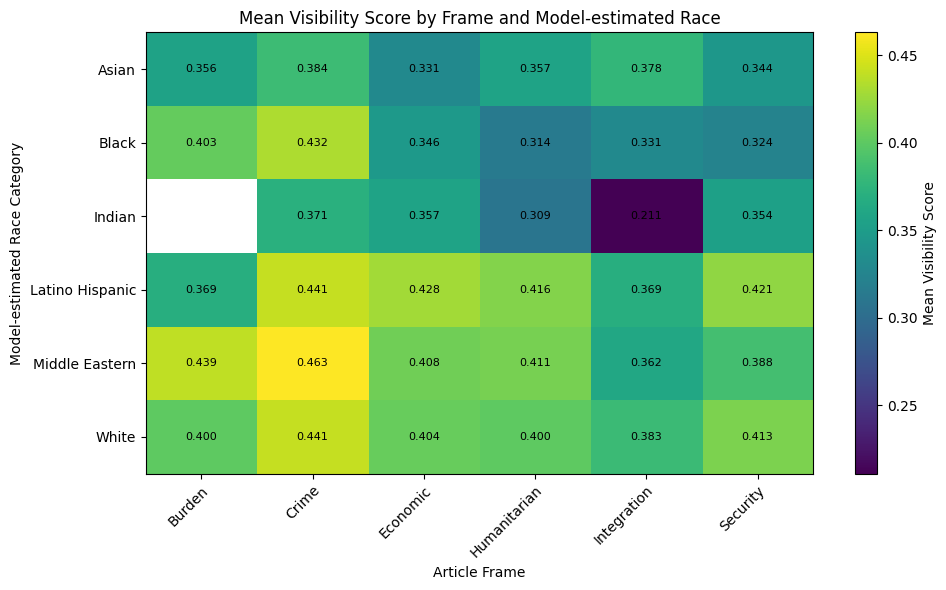

In [16]:
# Heatmap: mean visibility by frame and race
visibility_frame_race_heatmap = visibility_frame_race_table.pivot_table(
    index="Model-estimated Race",
    columns="Frame",
    values="Mean Visibility Score",
    aggfunc="mean"
).round(3)

display(visibility_frame_race_heatmap)

fig, ax = plt.subplots(figsize=(10, 6))

data = visibility_frame_race_heatmap.values
im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(visibility_frame_race_heatmap.columns)))
ax.set_yticks(np.arange(len(visibility_frame_race_heatmap.index)))

ax.set_xticklabels(visibility_frame_race_heatmap.columns)
ax.set_yticklabels(visibility_frame_race_heatmap.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(visibility_frame_race_heatmap.index)):
    for j in range(len(visibility_frame_race_heatmap.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8
            )

ax.set_title("Mean Visibility Score by Frame and Model-estimated Race")
ax.set_xlabel("Article Frame")
ax.set_ylabel("Model-estimated Race Category")

cbar = plt.colorbar(im)
cbar.set_label("Mean Visibility Score")

plt.tight_layout()
plt.show()